# WALMART PARQUINGS IMAGES

In this notebook we are going to extract all the satelite images from the parquings of Walmart's shops we have found, using the coordenates saved as the imput of a Google Engine Earth API. We will also filter out some images that doesen't have good sharpness, and won't allow us to do the study properly.

In [ ]:
import csv
import json
import os
import matplotlib.pyplot as plt
from PIL import Image
import requests
import ee
import cv2
import seaborn as sns
import numpy as np
from collections import Counter


Here we will ask for all the images since 2010 at the desired coordinates, and we will save them with the following format: store_id_date.png.

In [ ]:
# Initialize Earth Engine with your project ID
ee.Initialize(project="geospatial-485610")  

CSV_FILE_PATH = "../Data/walmart_coordinates.csv" 
OUTPUT_DIR = "/Users/gal.lagelpibuxade/Desktop/Application-of-Deep-learning-image/Data/naip_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Configuration of how many rows to process and the start date for image collection
N_ROWS_TO_PROCESS = 102 
START_DATE = "2010-01-01"

print(f"Starting capture of {N_ROWS_TO_PROCESS} stores...")
stores_processed = []

with open(CSV_FILE_PATH, mode="r", encoding="utf-8") as f:
  
    reader = csv.DictReader(f)

    for idx, row in enumerate(reader):
        if idx >= N_ROWS_TO_PROCESS:
            break

        store_id = row["store_id"]
        parking_coords_raw = row["parquing_coordenates"]

        try:
            # transform "[61.210712, -149.743302]" in [61.210712, -149.743302]
            coords = json.loads(parking_coords_raw)
            lat = coords[0]
            lon = coords[1]
        except Exception as e:
            print(
                f"Error parsing coordinates for store {store_id}: {e}"
            )
            continue

        print(
            f"\nProcessing Store ID: {store_id} (Lat: {lat}, Lon: {lon})..."
        )

        # Configuration of the region of interest (ROI) for Earth Engine
        point = ee.Geometry.Point([lon, lat])
        region = point.buffer(100).bounds()  

        # Filter the NAIP image collection for the given point and date range
        collection = (
            ee.ImageCollection("USDA/NAIP/DOQQ")
            .filterBounds(point)
            .filterDate(START_DATE, "2026-01-01")
            .sort("system:time_start")
        )

        try:
            n_imgs = collection.size().getInfo()
        except Exception as e:
            print(f"Error connecting to Earth Engine: {e}")
            continue

        print(f"NAIP images found: {n_imgs}")

        if n_imgs == 0:
            print("No images found for this store, skipping...")
            continue

        images_list = collection.toList(n_imgs)
        stores_processed.append(
            store_id
        ) 

        for i in range(n_imgs):
            img = ee.Image(images_list.get(i))
            date = img.date().format("YYYY-MM-dd").getInfo()

            # Format requested: ID_STORE_DATA -> Ej: 3591_2015-07-20.png
            filename = f"{store_id}_{date}.png"
            out_path = os.path.join(OUTPUT_DIR, filename)

            if os.path.exists(out_path):
                print(f"  {date} - Already downloaded, skipping...")
                continue

            print(f"  Downloading {date}...")

            try:
                url = img.select(["R", "G", "B"]).getThumbURL(
                    {
                        "region": region,
                        "dimensions": "1024x1024",
                        "format": "png",
                    }
                )

                response = requests.get(url)

                if response.status_code == 200:
                    with open(out_path, "wb") as img_f:
                        img_f.write(response.content)
                    print(f"Saved: {out_path}")
                else:
                    print(
                        f"Error {response.status_code}: {response.text[:200]}"
                    )
            except Exception as e:
                print(f"Error downloading image: {e}")

print("\nProcessing complete.")

Iniciando procesamiento de las primeras 102 tiendas...

Procesando Tienda ID: 3591 (Lat: 61.210712, Lon: -149.743302)...
  Imágenes NAIP encontradas: 0
  Nenhuma imagem encontrada para essa data/local.

Procesando Tienda ID: 1995 (Lat: 61.140247, Lon: -149.867127)...
  Imágenes NAIP encontradas: 0
  Nenhuma imagem encontrada para essa data/local.

Procesando Tienda ID: 1042 (Lat: 31.320724, Lon: -86.445818)...
  Imágenes NAIP encontradas: 7
  Baixando 2011-08-15...
    ✅ Salvo: /Users/gal.lagelpibuxade/Desktop/Application-of-Deep-learning-image/Data/naip_images/1042_2011-08-15.png
  Baixando 2013-09-27...
    ✅ Salvo: /Users/gal.lagelpibuxade/Desktop/Application-of-Deep-learning-image/Data/naip_images/1042_2013-09-27.png
  Baixando 2015-08-04...
    ✅ Salvo: /Users/gal.lagelpibuxade/Desktop/Application-of-Deep-learning-image/Data/naip_images/1042_2015-08-04.png
  Baixando 2017-09-09...
    ✅ Salvo: /Users/gal.lagelpibuxade/Desktop/Application-of-Deep-learning-image/Data/naip_images/104

KeyboardInterrupt: 

States without pictures: HI (Hawaii), AK (Alaska)

#### SHARPNESS

First we plot the five images with less sharpness to see what we are working with:

Analizando la nitidez de las imágenes...

🚨 LAS 5 IMÁGENES CON PEOR RESOLUCIÓN/NITIDEZ:
   1. 3668_2012-07-11.png -> Score: 21.06
   2. 3078_2014-07-21.png -> Score: 23.60
   3. 4586_2017-08-19.png -> Score: 23.70
   4. 3091_2012-06-01.png -> Score: 26.60
   5. 380_2017-09-10.png -> Score: 27.30



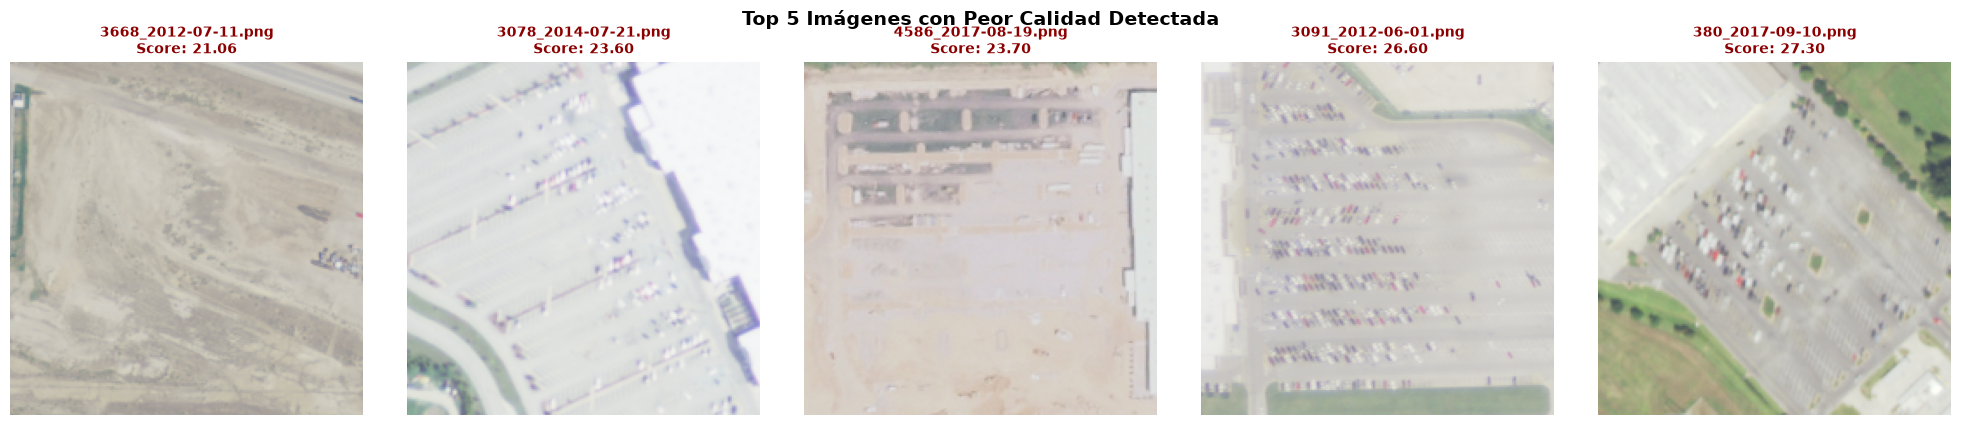

In [ ]:
OUTPUT_DIR = "/Users/gal.lagelpibuxade/Desktop/Application-of-Deep-learning-image/Data/naip_images"

if not os.path.exists(OUTPUT_DIR):
    print(f"The directory does not exist: {OUTPUT_DIR}")
    exit()

files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith(".png")]

if not files:
    print(f"No image files found in: {OUTPUT_DIR}")
    exit()

quality_list = []

print("Analizing the sharpness of the images...")

for fname in files:
    img_path = os.path.join(OUTPUT_DIR, fname)
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        continue
    score = cv2.Laplacian(img_gray, cv2.CV_64F).var()
    
    quality_list.append((fname, score))

# Sort the list of images by their sharpness score (lower scores indicate worse quality)
quality_list.sort(key=lambda x: x[1])

# Keep the 5 worst images (or fewer if there are less than 5 in total)
peores_5 = quality_list[:5]

print("\n" + "="*50)
print("Top 5 Worst Images:")
for idx, (fname, score) in enumerate(peores_5, start=1):
    print(f"   {idx}. {fname} -> Score: {score:.2f}")
print("="*50 + "\n")

# Plot the 5 worst images
num_graphics = len(peores_5)
fig, axes = plt.subplots(1, num_graphics, figsize=(4 * num_graphics, 4))
if num_graphics == 1:
    axes = [axes]

for ax, (fname, score) in zip(axes, peores_5):
    img_path = os.path.join(OUTPUT_DIR, fname)
    img_display = Image.open(img_path)
    
    ax.imshow(img_display)
    ax.set_title(f"{fname}\nScore: {score:.2f}", color="darkred", fontsize=10, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.suptitle("Top 5 Images with Worst Quality", fontsize=14, fontweight="bold", y=1.05)
plt.show()

Let's print some statistics about the sharpness in our dataset, to decide if we can drop part of the images with bad quality.

Analizando nitidez de 713 imágenes...

📊 ESTADÍSTICAS DE NITIDEZ:
   • Mínimo Score: 21.06
   • Máximo Score: 1814.18
   • Media (Promedio): 250.51
   • Mediana (Corte 50%): 193.85
   • Primer Cuartil (Peores 25%): 117.89



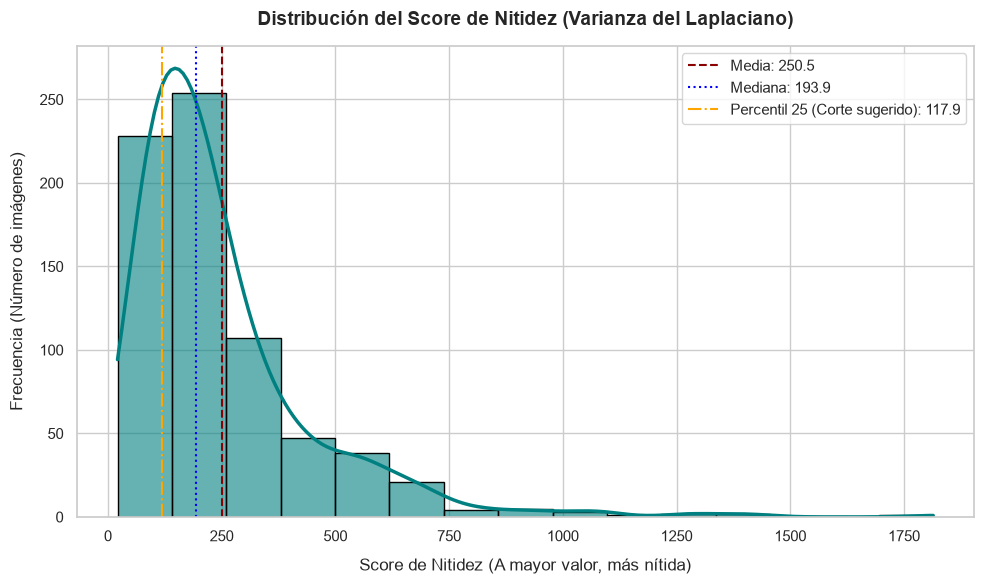

In [ ]:
OUTPUT_DIR = "/Users/gal.lagelpibuxade/Desktop/Application-of-Deep-learning-image/Data/naip_images"

# Get sharpness scores for all images in the directory
if not os.path.exists(OUTPUT_DIR):
    print(f"The directory does not exist: {OUTPUT_DIR}")
    exit()

files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith(".png")]

if not files:
    print(f"No image files found in: {OUTPUT_DIR}")
    exit()

scores = []

print(f"Analizing sharpness of {len(files)} images...")

for fname in files:
    img_path = os.path.join(OUTPUT_DIR, fname)
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img_gray is None:
        continue
    score = cv2.Laplacian(img_gray, cv2.CV_64F).var()
    scores.append(score)

# Compute basic descriptive statistics
scores = np.array(scores)
mean = np.mean(scores)
median = np.median(scores)
q25 = np.percentile(scores, 25)

print("\n" + "="*40)
print("📊 SHARPNESS STATISTICS:")
print(f"   • Minimum Score: {scores.min():.2f}")
print(f"   • Maximum Score: {scores.max():.2f}")
print(f"   • Mean: {mean:.2f}")
print(f"   • Median (Cut 50%): {median:.2f}")
print(f"   • Percentile 25 (Worst 25%): {q25:.2f}")
print("="*40 + "\n")

# Plotting the distribution of sharpness scores
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.histplot(scores, kde=True, color="teal", bins=15, edgecolor="black", alpha=0.6, line_kws={"linewidth": 2.5})
plt.axvline(mean, color="darkred", linestyle="--", linewidth=1.5, label=f"Mean: {mean:.1f}")
plt.axvline(median, color="blue", linestyle=":", linewidth=1.5, label=f"Median: {median:.1f}")
plt.axvline(q25, color="orange", linestyle="-.", linewidth=1.5, label=f"Percentile 25 (Suggested Cut): {q25:.1f}")
plt.title("Distribution of Sharpness Scores (Variance of Laplacian)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Sharpness Score (Higher Value, More Sharp)", fontsize=12, labelpad=10)
plt.ylabel("Frequency (Number of Images)", fontsize=12, labelpad=10)
plt.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()

Based on the statistics and the fact that an image is considered good with a sharpness above 100, we will keep only those with a sharpness of 110 or higher. First we study how many images we will be dropping and then we delete them.

Buscando imágenes con nitidez ≥ 110.0...
--------------------------------------------------
📊 RESULTADO DEL FILTRADO ALTA CALIDAD (≥ 110.0):
   • Total de imágenes analizadas: 713
   • Total que cumplen el criterio: 559
--------------------------------------------------
   • Año 2010: 45 imágenes excelentes
   • Año 2011: 37 imágenes excelentes
   • Año 2012: 35 imágenes excelentes
   • Año 2013: 44 imágenes excelentes
   • Año 2014: 32 imágenes excelentes
   • Año 2015: 40 imágenes excelentes
   • Año 2016: 34 imágenes excelentes
   • Año 2017: 38 imágenes excelentes
   • Año 2018: 44 imágenes excelentes
   • Año 2019: 32 imágenes excelentes
   • Año 2020: 27 imágenes excelentes
   • Año 2021: 48 imágenes excelentes
   • Año 2022: 40 imágenes excelentes
   • Año 2023: 63 imágenes excelentes
--------------------------------------------------


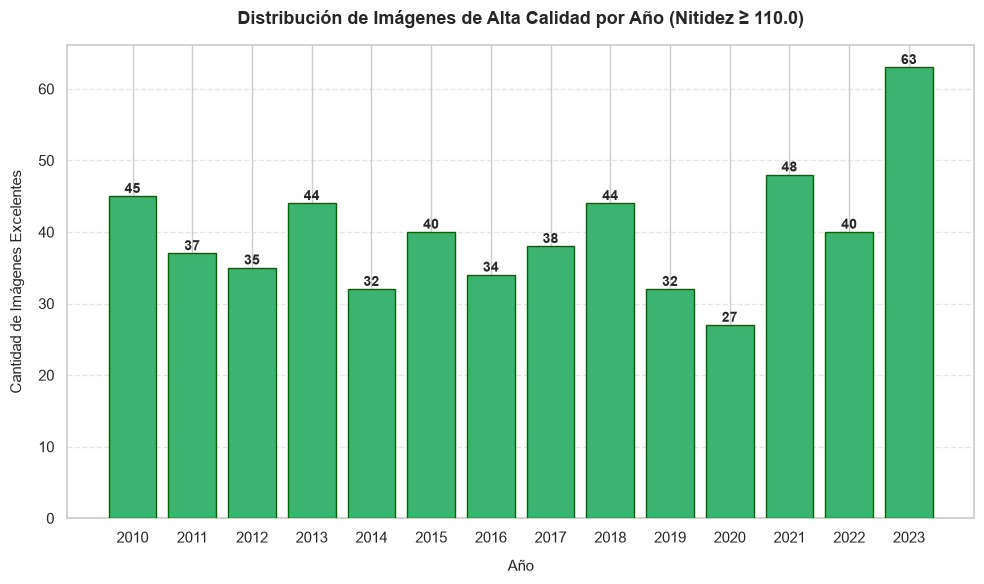

In [ ]:
OUTPUT_DIR = "/Users/gal.lagelpibuxade/Desktop/Application-of-Deep-learning-image/Data/naip_images"

# Define the threshold for excellent quality images
EXELENT_THRESHOLD = 110.0

if not os.path.exists(OUTPUT_DIR):
    print(f"The directory does not exist: {OUTPUT_DIR}")
    exit()

files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith(".png")]

if not files:
    print(f"No image files found in: {OUTPUT_DIR}")
    exit()

excelent_images = []
total_analized = 0

print(f"Searching for images with sharpness ≥ {EXELENT_THRESHOLD}...")

for fname in files:
    img_path = os.path.join(OUTPUT_DIR, fname)
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        continue  
    total_analized += 1
    score = cv2.Laplacian(img_gray, cv2.CV_64F).var()
    
    # Apply the strict quality filter
    if score >= EXELENT_THRESHOLD:
        name_no_ext = os.path.splitext(fname)[0]
        parts = name_no_ext.split('_')
        
        if len(parts) >= 2:
            date = parts[-1]
            year = date.split('-')[0]
            
            if year.isdigit() and len(year) == 4:
                excelent_images.append(int(year))

# Count how many excellent images there are per year
year_counts = Counter(excelent_images)
years_sorted = sorted(year_counts.keys())
quantities = [year_counts[year] for year in years_sorted]

# Print the statistics
print("-" * 50)
print(f"FINAL RESULTS FILTER (≥ {EXELENT_THRESHOLD}):")
print(f"   • Total images analyzed: {total_analized}")
print(f"   • Total that meet the criterion: {len(excelent_images)}")
print("-" * 50)
for year in years_sorted:
    print(f"   • Year {year}: {year_counts[year]} excellent images")
print("-" * 50)

# Plot the results
if not excelent_images:
    print(f"None of your images reached a score of {EXELENT_THRESHOLD}. Try lowering the threshold a bit.")
    exit()

plt.figure(figsize=(10, 6))
bars = plt.bar([str(year) for year in years_sorted], quantities, color='mediumseagreen', edgecolor='darkgreen', zorder=3)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.05, int(yval), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title(f"Distribution of High-Quality Images by Year (Sharpness ≥ {EXELENT_THRESHOLD})", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=11, labelpad=10)
plt.ylabel("Number of Excellent Images", fontsize=11, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
plt.gca().yaxis.get_major_locator().set_params(integer=True)
plt.tight_layout()
plt.show()

In [ ]:
OUTPUT_DIR = "/Users/gal.lagelpibuxade/Desktop/Application-of-Deep-learning-image/Data/naip_images"

CUTOFF_THRESHOLD = 110.0
if not os.path.exists(OUTPUT_DIR):
    print(f"The directory does not exist: {OUTPUT_DIR}")
    exit()

# List all PNG images in the directory
files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith(".png")]
total_inicial= len(files)

if total_inicial == 0:
    print(f"No image files found in: {OUTPUT_DIR}")
    exit()

print(f"Starting analysis in: {OUTPUT_DIR}")
print(f"Analyzing {total_inicial} images. Minimum threshold required: {CUTOFF_THRESHOLD}")
print("-" * 60)

imagenes_deleted = 0
imagenes_saved = 0

for fname in files:
    img_path = os.path.join(OUTPUT_DIR, fname)
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img_gray is None:
        print(f"Can't read {fname} -> Skipping")
        continue
        
    score = cv2.Laplacian(img_gray, cv2.CV_64F).var()
    if score < CUTOFF_THRESHOLD:
        try:
            os.remove(img_path) 
            print(f"DELETED: {fname} (Score: {score:.2f})")
            imagenes_deleted += 1
        except Exception as e:
            print(f"Error deleting {fname}: {e}")
    else:
        print(f"SAVED: {fname} (Score: {score:.2f})")
        imagenes_saved += 1

# Summarize the cleanup results
print("-" * 60)
print("Summary:")
print(f"   • Total initial images: {total_inicial}")
print(f"   • Deleted images (Score < {CUTOFF_THRESHOLD}): {imagenes_deleted}")
print(f"   • Saved images (Score ≥ {CUTOFF_THRESHOLD}): {imagenes_saved}")
print("-" * 60)
print("Cleanup completed successfully!")

Iniciando purga en: /Users/gal.lagelpibuxade/Desktop/Application-of-Deep-learning-image/Data/naip_images
Se van a analizar 713 imágenes. Umbral mínimo requerido: 110.0
------------------------------------------------------------
✅ CONSERVADA: 2690_2010-08-19.png (Score: 149.34)
✅ CONSERVADA: 3276_2019-08-14.png (Score: 392.28)
✅ CONSERVADA: 3311_2023-10-08.png (Score: 153.35)
✅ CONSERVADA: 3345_2022-07-22.png (Score: 153.88)
✅ CONSERVADA: 4413_2013-10-26.png (Score: 152.86)
❌ BORRADA: 1895_2012-08-17.png (Score: 75.88)
✅ CONSERVADA: 2597_2013-08-30.png (Score: 306.84)
✅ CONSERVADA: 1792_2010-07-15.png (Score: 141.66)
✅ CONSERVADA: 3725_2018-10-22.png (Score: 215.47)
✅ CONSERVADA: 2063_2012-07-13.png (Score: 161.82)
✅ CONSERVADA: 1530_2010-07-01.png (Score: 565.99)
✅ CONSERVADA: 3345_2015-06-20.png (Score: 165.89)
❌ BORRADA: 4586_2019-09-10.png (Score: 80.18)
✅ CONSERVADA: 812_2012-06-13.png (Score: 274.93)
❌ BORRADA: 42_2019-07-18.png (Score: 91.29)
✅ CONSERVADA: 552_2012-06-15.png (Sc